# 1. Загрузка данных

In [14]:
# Библиотеки для работы с данными
import pandas as pd
import numpy as np
from collections import defaultdict
from collections import Counter

# Библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from matplotlib.ticker import FuncFormatter

# Библиотеки для работы с текстом
import re
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer

# Библиотеки для работы с картами
import folium

# Библиотеки для машинного обучения
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

# Дополнительные библиотеки
import ast
import random

from scipy.stats import spearmanr
from scipy.stats import kruskal

In [16]:
import statsmodels.formula.api as smf
import geohash2
import folium
from folium import Element

In [20]:
import geopandas as gpd
from libpysal.weights import KNN
from esda.moran import Moran_Local
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [6]:
#Загрузим даатсет с вакансиями
data = pd.read_csv ('hh_2024_sample.csv', low_memory=False)

In [18]:
data = data.drop(['premium',
              'relations',
              'insider_interview',
              'response_letter_required',
              'salary',
              'allow_messages',
              'department',
              'contacts',
              'vacancy_constructor_template',
              'archived',
              'specializations',
              'code',
              'hidden',
              'quick_responses_allowed',
              'accept_incomplete_resumes',
              'created_at',
              'initial_created_at',
              'negotiations_url',
              'suitable_resumes_url',
              'apply_alternate_url',
              'test',
              'address.description',
              'address.metro',
              'employer.logo_urls',
              'department.id',
              'year'], axis=1)

In [22]:
data = data.drop_duplicates(subset='id', keep='first')

In [24]:
duplicate_description = data.duplicated(subset=['name', 
                                       'description', 
                                       'branded_description',
                                       'key_skills',
                                       'professional_roles',
                                       'area.id',
                                       'address.city',
                                       'experience.id',
                                       'employment.id',
                                       'employer.id',
                                       'salary.from',
                                       'salary.gross',
                                        ### вторичный уровень влияния
                                       'accept_handicapped',
                                       'accept_kids',
                                       'working_days',
                                       'working_time_intervals',
                                       'working_time_modes',
                                       'accept_temporary',
                                       'languages',
                                       'driver_license_types',
                                       'schedule.id',
                                       'employment.id',
                                       'internship',
                                       'night_shifts',
                                       'work_format',
                                       'working_hours' ], keep='first')

In [28]:
data = data[~duplicate_description]

In [30]:
#Подгрузим данные о регионах РФ, чтобы оставить в выборке только те вакансии, которые относятся к РФ
data_prof = pd.read_excel('data_RUR_with_region_2704.xlsx')

In [34]:
df = data.merge(data_prof, on='id', how='inner')

In [38]:
df = df[df['id'] != 99159786]

In [40]:
if isinstance(df['professional_roles'].iloc[0], str):
    df['professional_roles'] = df['professional_roles'].apply(ast.literal_eval)

In [42]:
df['role_id'] = df['professional_roles'].apply(lambda x: x[0]['id'])
df['role_name'] = df['professional_roles'].apply(lambda x: x[0]['name'])

In [275]:
#выделим роли, которые относятся к отрасли Торговля
target_ids = {'97','70','9','35','129','106'}
df_prod = df[df['role_id'].isin(target_ids)].copy()

In [277]:
#Создадим итоговый датасет 
df_prod = df_prod[['name',
              'description',
              'role_id',
              'role_name',
              'key_skills',
              'experience.id',
              'experience.name',
              'schedule.id',
              'schedule.name',
              'employment.id',
              'employment.name',
              'address.lat_2',
              'address.lng_2',
              'address.city_new',
              'region_name',
              'salary.from',
              'salary.gross']].copy()

# 2. Анализ данных

In [279]:
df_prod.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 147338 entries, 26336 to 703318
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   name              147338 non-null  object 
 1   description       147338 non-null  object 
 2   role_id           147338 non-null  object 
 3   role_name         147338 non-null  object 
 4   key_skills        63787 non-null   object 
 5   experience.id     147338 non-null  object 
 6   experience.name   147338 non-null  object 
 7   schedule.id       147338 non-null  object 
 8   schedule.name     147338 non-null  object 
 9   employment.id     147338 non-null  object 
 10  employment.name   147338 non-null  object 
 11  address.lat_2     110022 non-null  float64
 12  address.lng_2     110022 non-null  float64
 13  address.city_new  109623 non-null  object 
 14  region_name       147338 non-null  object 
 15  salary.from       147338 non-null  float64
 16  salary.gross    

In [281]:
df_prod = df_prod.rename(columns={
    'experience.name': 'experience_name',
    'experience.id': 'experience_id',
    'schedule.id': 'schedule_id',
    'employment.id': 'employment_id'})

In [283]:
df_prod.duplicated().sum()

6549

In [285]:
#удалим полные дубликаты
df_prod = df_prod.drop_duplicates().copy()

In [287]:
df_prod.shape

(140789, 17)

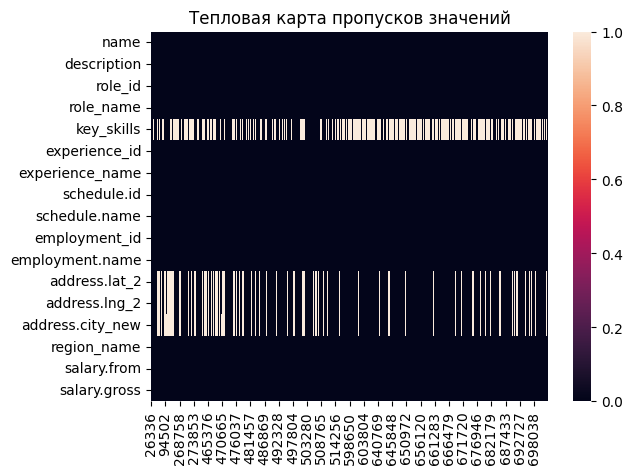

In [131]:
#Проверим пропуски
sns.heatmap(df_prod.isna().T)
plt.title('Тепловая карта пропусков значений')
plt.show()

Пропуски есть в признаках:
* key_skills - с информацией о навыках
* address.lat_2, address.lng_2, address.city_new - точных координатах вакансии и названии населенного пункта

In [134]:
#Проверим % пропусков для 'address.lat_2', 'address.lng_2', 'address.city_new'
cols_to_check = ['address.lat_2', 'address.lng_2', 'address.city_new']

for col in cols_to_check:
    print(col)
    print('Пропусков:', df_prod[col].isna().sum())
    print('Доля:', round(df_prod[col].isna().mean() * 100, 2), '%')
    print('---')

address.lat_2
Пропусков: 32079
Доля: 22.79 %
---
address.lng_2
Пропусков: 32079
Доля: 22.79 %
---
address.city_new
Пропусков: 32474
Доля: 23.07 %
---


In [289]:
#Проверим что пропуски по координатам почти полностью совпадают с пропуками по имени населенного пункта
(df_prod['address.lat_2'].isna() != df_prod['address.city_new'].isna()).sum()

395

In [174]:
cols_to_check = ['role_id', 'role_name', 'experience_id', 'experience_name',
                 'schedule.id', 'schedule.name', 'employment_id', 'employment.name']

In [176]:
for col in cols_to_check:
    unique_vals = df_prod[col].unique()
    num_unique = df_prod[col].nunique()
    print(f"Признак: {col}")
    print(f"Количество уникальных значений: {num_unique}")
    print(f"Уникальные значения: {unique_vals}")
    print("-" * 50)

Признак: role_id
Количество уникальных значений: 6
Уникальные значения: ['106' '129' '35' '70' '9' '97']
--------------------------------------------------
Признак: role_name
Количество уникальных значений: 6
Уникальные значения: ['Руководитель отдела продаж' 'Торговый представитель'
 'Директор магазина, директор сети магазинов'
 'Менеджер по продажам, менеджер по работе с клиентами'
 'Администратор магазина, администратор торгового зала'
 'Продавец-консультант, продавец-кассир']
--------------------------------------------------
Признак: experience_id
Количество уникальных значений: 4
Уникальные значения: ['between1And3' 'between3And6' 'noExperience' 'moreThan6']
--------------------------------------------------
Признак: experience_name
Количество уникальных значений: 4
Уникальные значения: ['От 1 года до 3 лет' 'От 3 до 6 лет' 'Нет опыта' 'Более 6 лет']
--------------------------------------------------
Признак: schedule.id
Количество уникальных значений: 5
Уникальные значения: ['fu

In [291]:
#закодируем опыт
experience_mapping = {
    'noExperience': 0,
    'between1And3': 1,
    'between3And6': 2,
    'moreThan6': 3
}
df_prod['experience_ord'] = df_prod['experience_id'].map(experience_mapping)

In [ ]:
Проанализируем зарплату

In [293]:
df_prod['salary.gross'].value_counts(dropna=False)

True     75758
False    64980
NaN         51
Name: salary.gross, dtype: int64

In [295]:
#Удалим строки, c Nan
df_prod = df_prod[df_prod['salary.gross'].notna()].copy()

In [297]:
df_prod.shape

(140738, 18)

In [299]:
# Для встрех строк, где зарплата указана с учетом вычета налога - преобразуем в зарплату до вычета налога
TAX_RATE = 0.13

mask_net = df_prod['salary.gross'] == False

df_prod.loc[mask_net, 'salary_from_adj'] = round(df_prod.loc[mask_net, 'salary.from'] / (1 - TAX_RATE),0)
df_prod.loc[~mask_net, 'salary_from_adj'] = df_prod.loc[~mask_net, 'salary.from']

In [160]:
df_prod[['salary.from','salary.gross', 'salary_from_adj']].head()

,salary.from,salary.gross,salary_from_adj
26336,100000.0,True,100000.0
26337,150000.0,False,172414.0
26338,150000.0,False,172414.0
26339,65000.0,False,74713.0
26340,256000.0,True,256000.0


In [301]:
#посмотрим количество строк с зарплатой меньше мрот 19 242
df_prod[df_prod['salary_from_adj'] < 19242].shape

(1765, 19)

Text(0, 0.5, 'Количество вакансий')

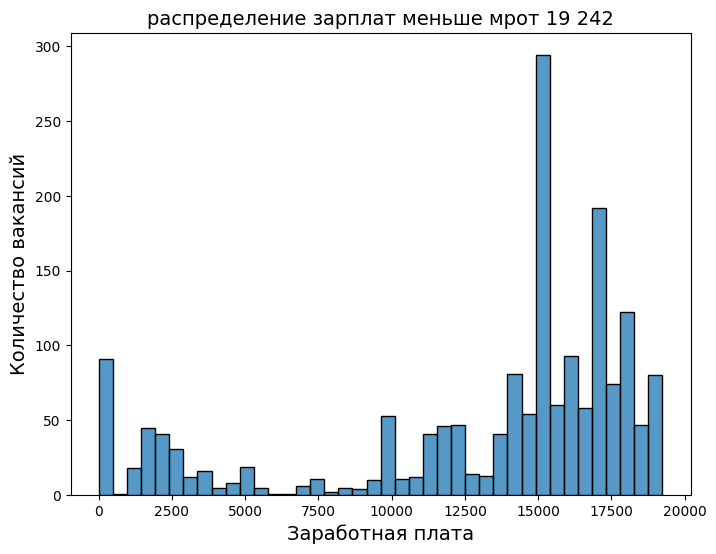

In [164]:
# посмотрим распределение зарплат меньше мрот 19 242
plt.figure(figsize=(8, 6))
sns.histplot(df_prod[df_prod['salary_from_adj'] < 19242]['salary_from_adj'], bins = 40) 
plt.title('распределение зарплат меньше мрот 19 242', fontsize=14)
plt.xlabel('Заработная плата', fontsize=14)
plt.ylabel('Количество вакансий', fontsize=14)

In [303]:
# удалим строки с зарплатой меньше мрот 19 242
df_prod = df_prod[df_prod['salary_from_adj'] >= 19242].copy()

In [305]:
df_prod.shape

(138973, 19)

In [307]:
df_prod = df_prod[df_prod['salary_from_adj'] < 10000000]

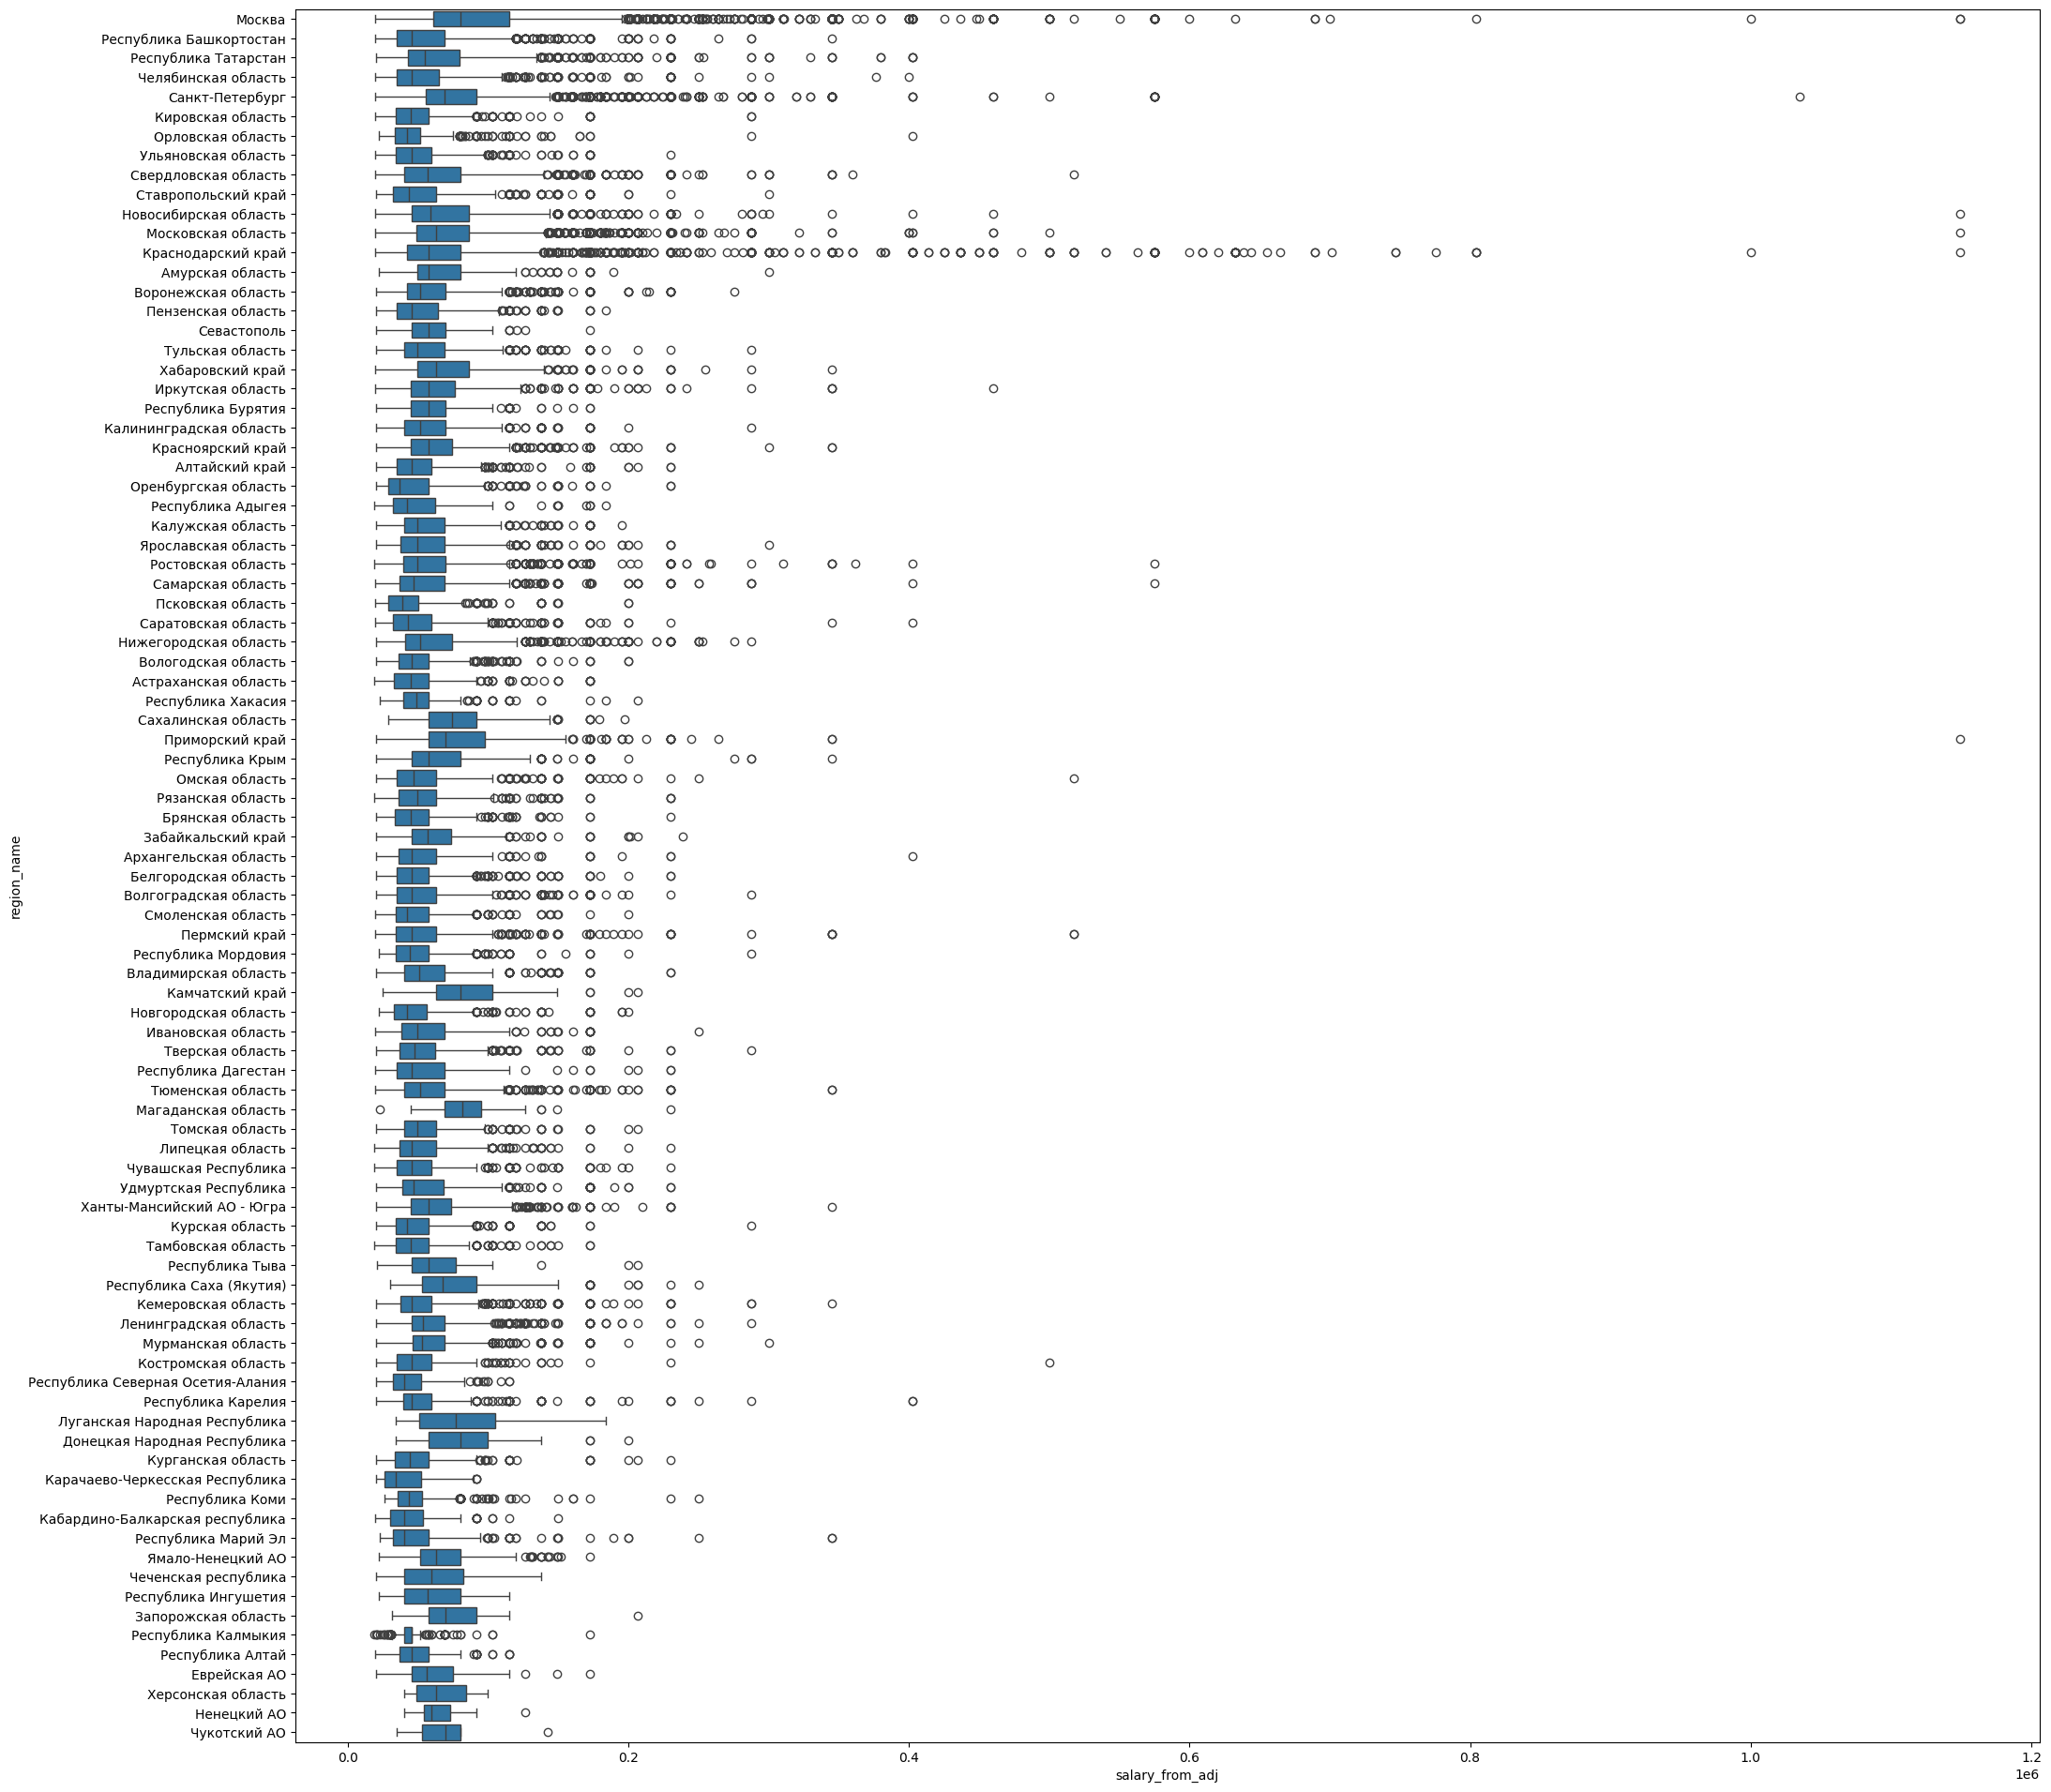

In [180]:
#Анализ по регионам топ-200 по количеству вакансий
top_regions = df_prod['region_name'].value_counts().head(200).index

plt.figure(figsize=(24,24))
sns.boxplot(
    data=df_prod[df_prod['region_name'].isin(top_regions)],
    x='salary_from_adj',
    y='region_name'
)
#plt.xlim(0, 6)
plt.show()

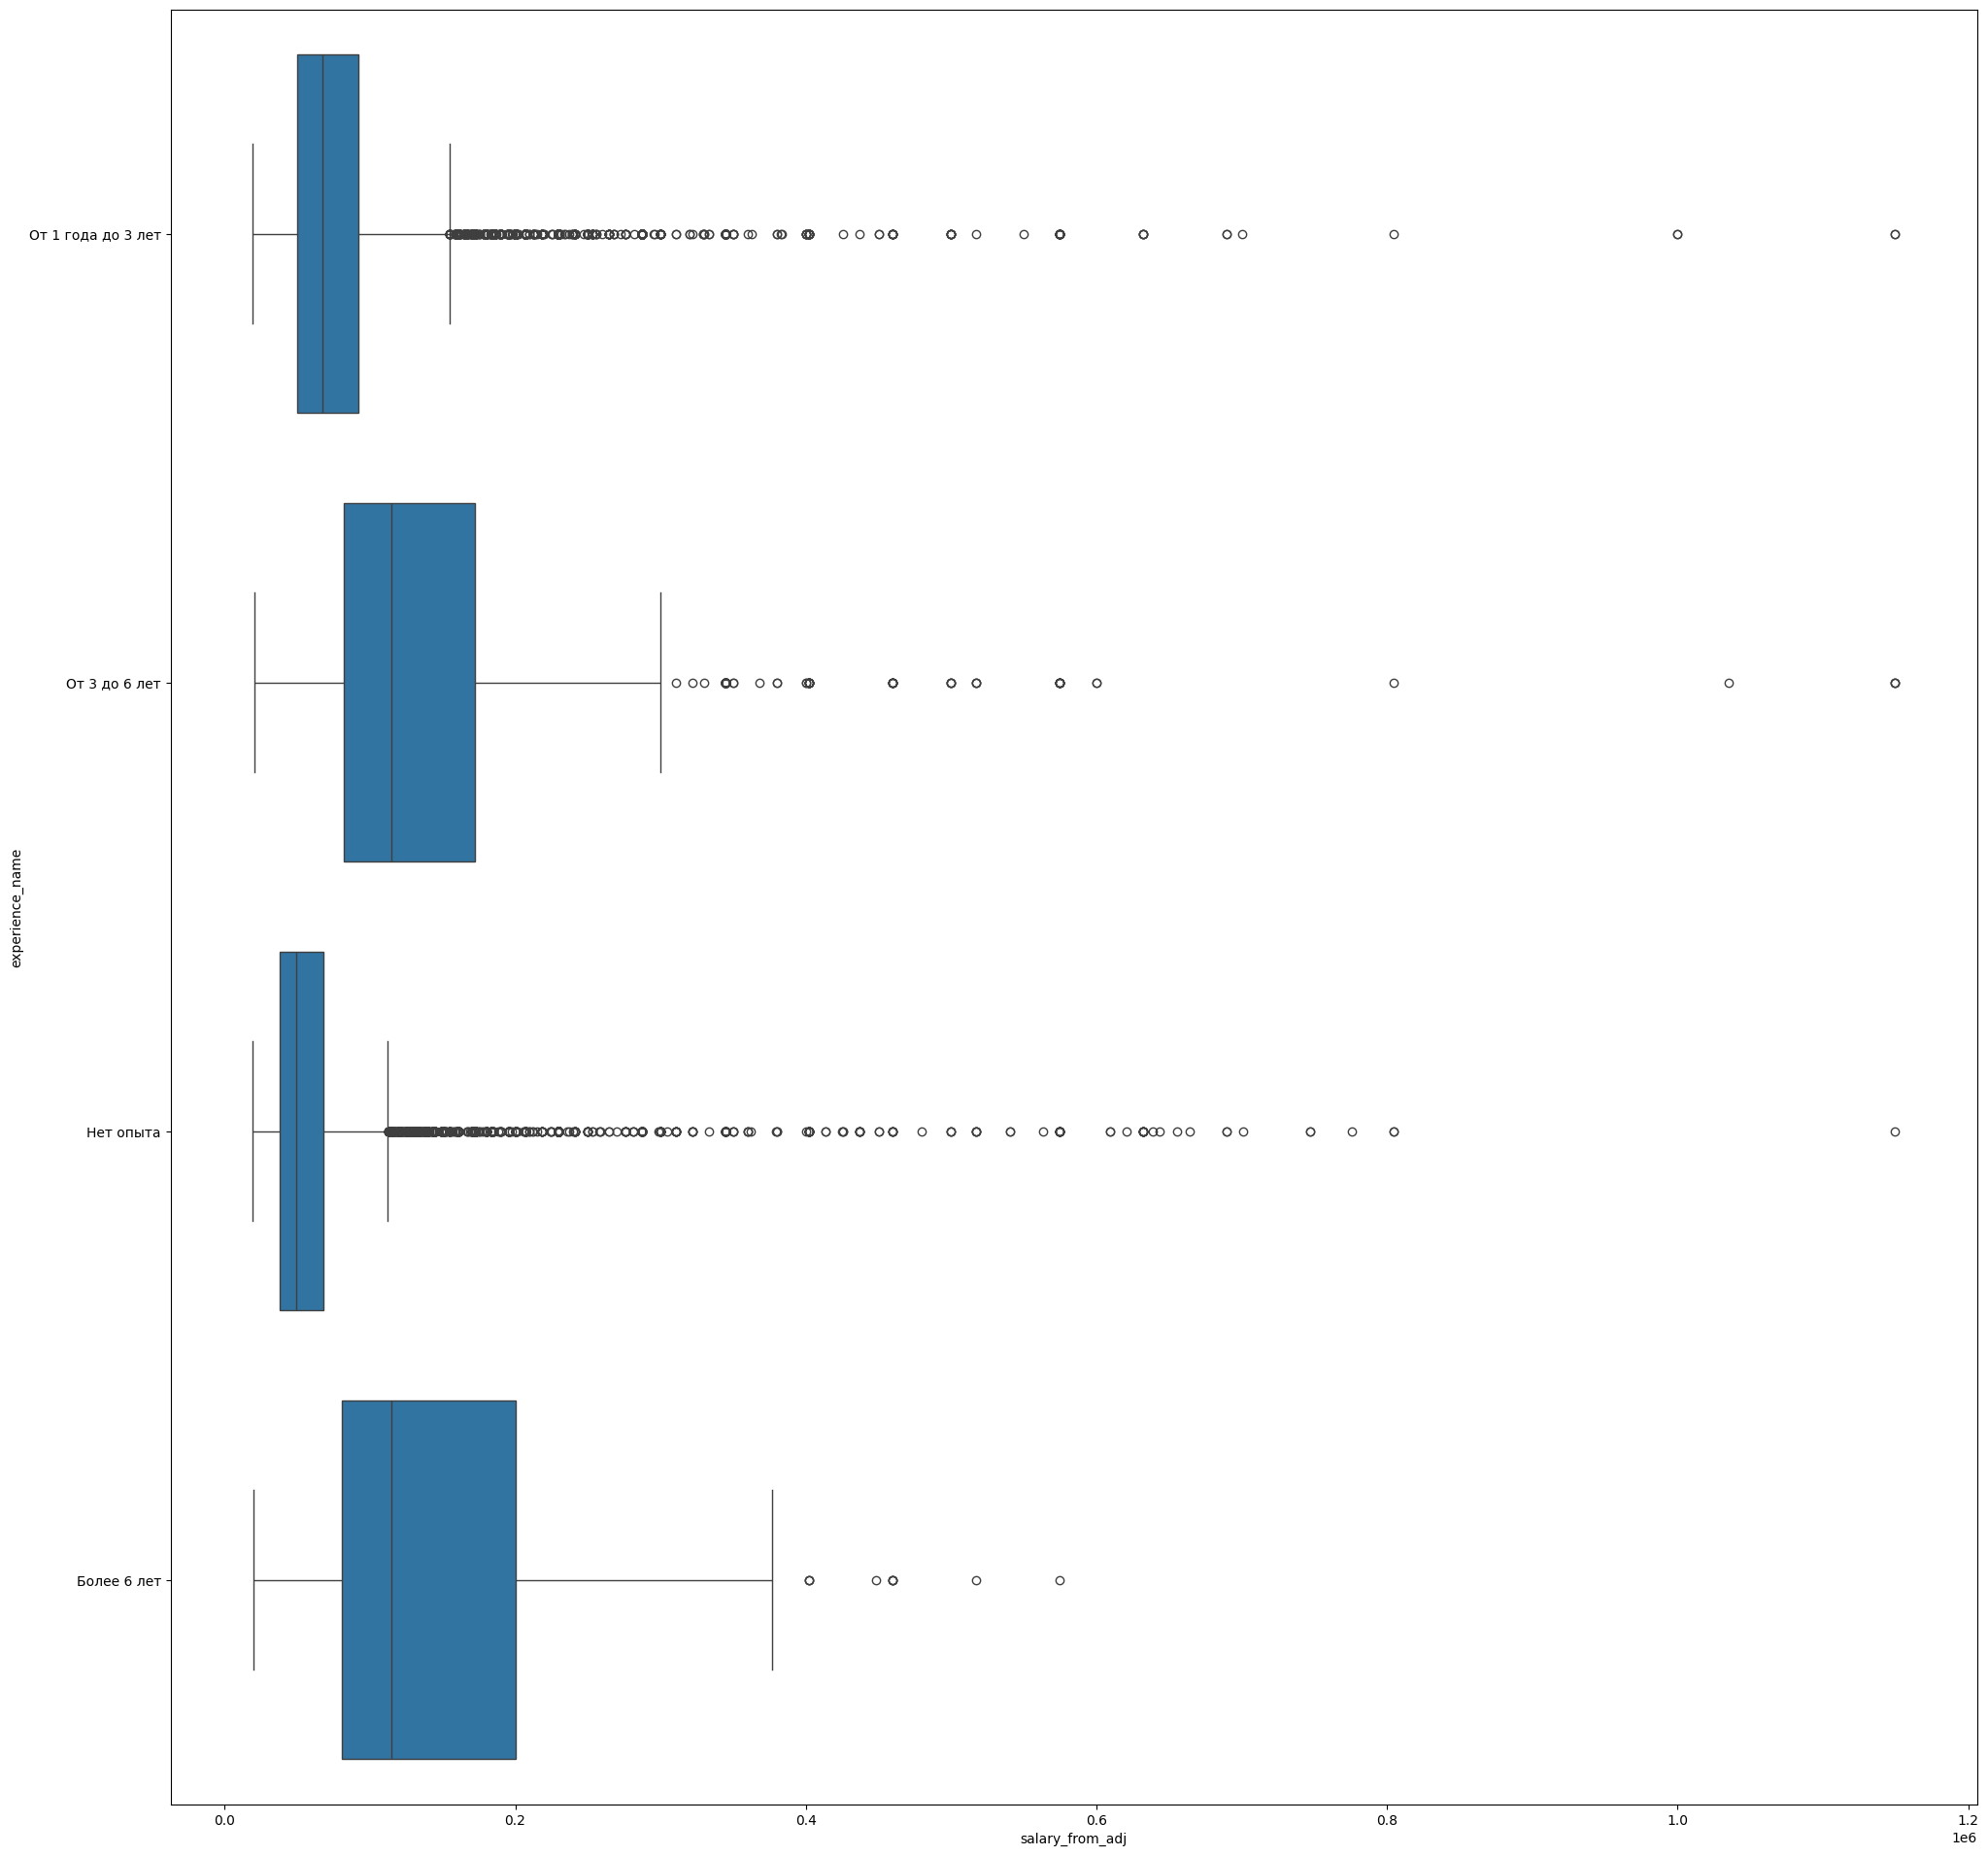

In [182]:
#Анализ по регионам топ-200 по количеству вакансий
top_regions = df_prod['experience_name'].value_counts().head(200).index

plt.figure(figsize=(24,24))
sns.boxplot(
    data=df_prod[df_prod['experience_name'].isin(top_regions)],
    x='salary_from_adj',
    y='experience_name'
)
#plt.xlim(0, 6)
plt.show()

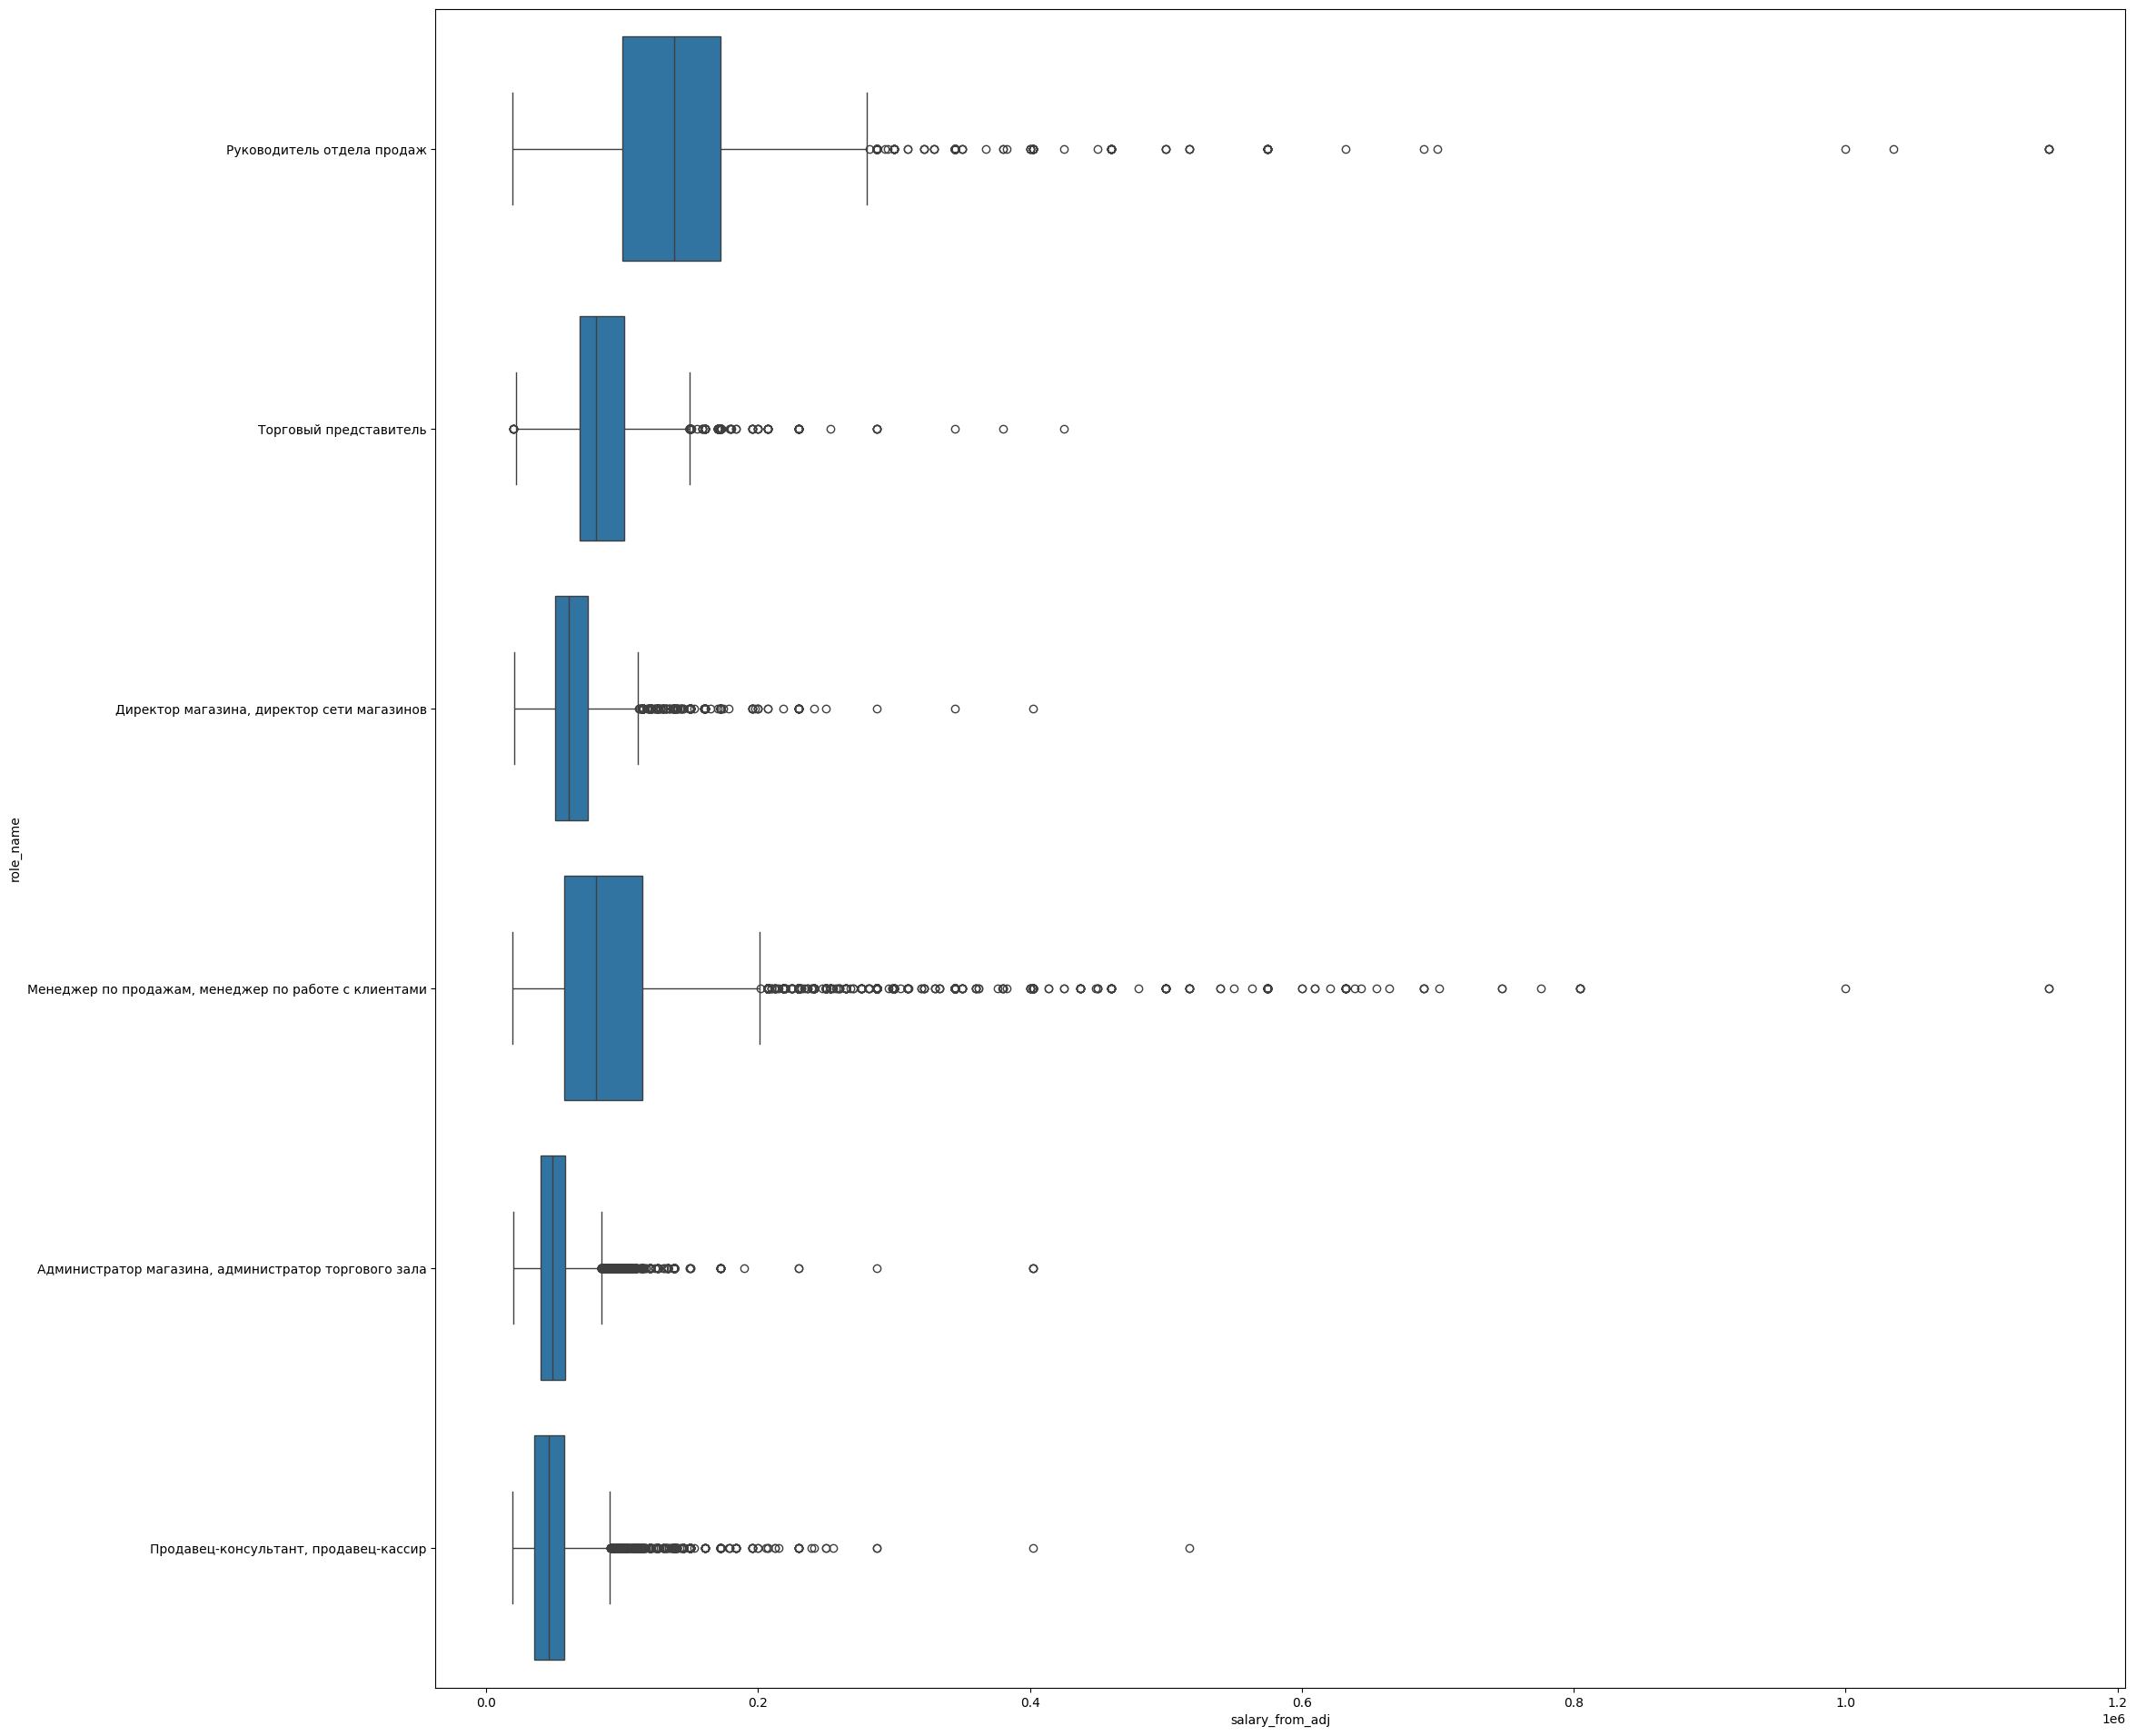

In [184]:
#Анализ по регионам топ-200 по количеству вакансий
top_regions = df_prod['role_name'].value_counts().head(200).index

plt.figure(figsize=(24,24))
sns.boxplot(
    data=df_prod[df_prod['role_name'].isin(top_regions)],
    x='salary_from_adj',
    y='role_name'
)
#plt.xlim(0, 6)
plt.show()

In [309]:
print("Исходное количество записей:", df_prod.shape[0])

Исходное количество записей: 138972


In [311]:
#удалим выбросы по зп в группах ('region_name', 'role_name', 'experience_name')
min_group_size = 10
def remove_outliers_iqr_safe(group, col='salary_from_adj'):
    if len(group) < min_group_size:
        return group
    q1 = group[col].quantile(0.25)
    q3 = group[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return group[(group[col] >= lower) & (group[col] <= upper)]

df_prod = df_prod.groupby(
    ['region_name', 'role_name', 'experience_name'], group_keys=False
).apply(remove_outliers_iqr_safe)

In [313]:
print("После удаления крайних 1% в группах:", df_prod.shape[0])

После удаления крайних 1% в группах: 132540


Text(0, 0.5, 'Количество вакансий')

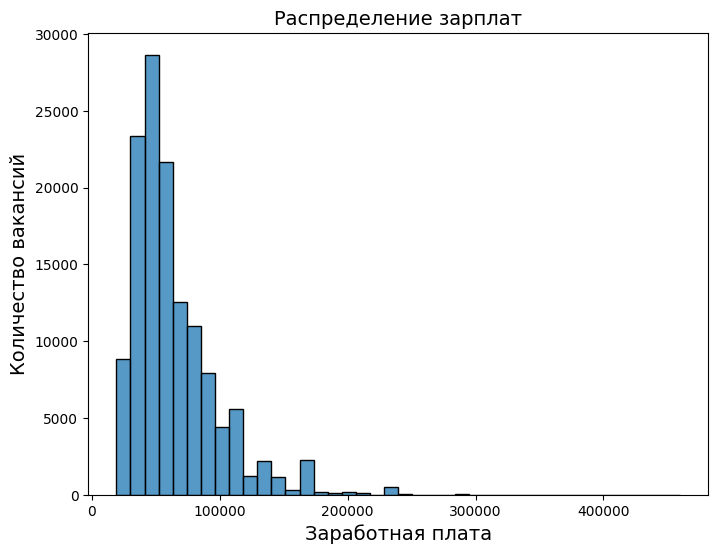

In [198]:
plt.figure(figsize=(8, 6))
sns.histplot(df_prod['salary_from_adj'], bins = 40) 
plt.title('Распределение зарплат', fontsize=14)
plt.xlabel('Заработная плата', fontsize=14)
plt.ylabel('Количество вакансий', fontsize=14)

<Axes: xlabel='salary_from_adj'>

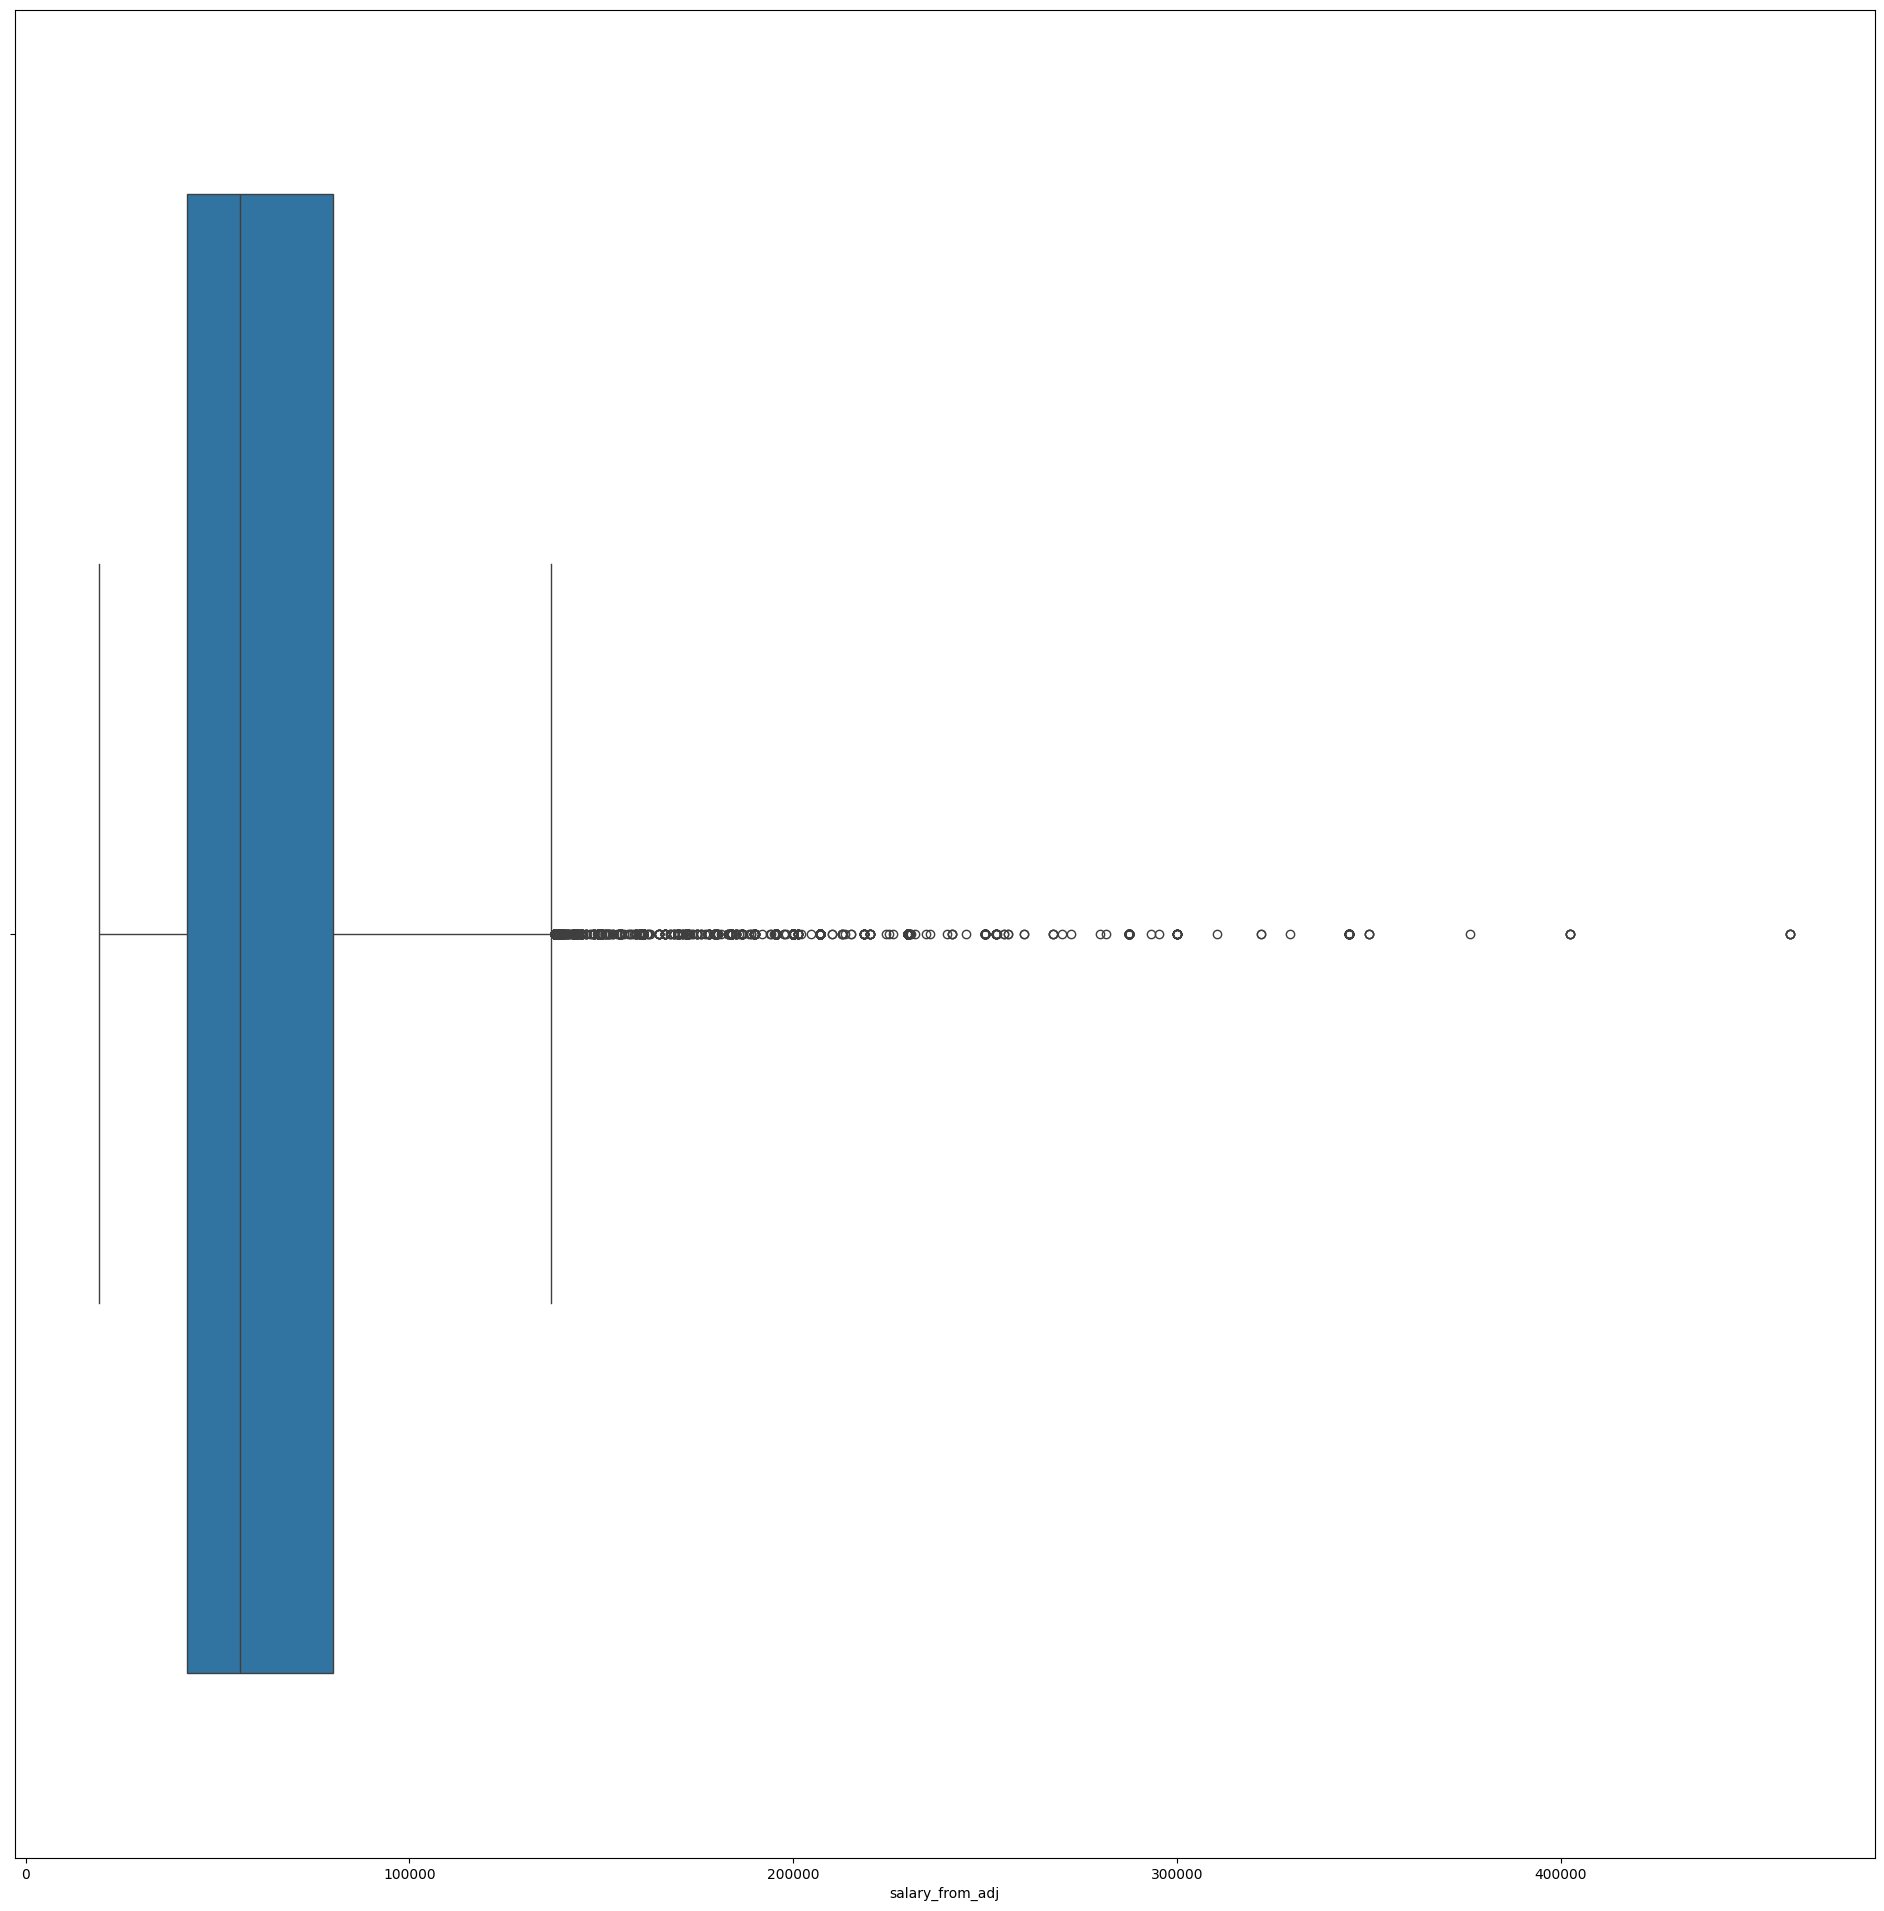

In [202]:
plt.figure(figsize=(24,24))
sns.boxplot(
    data=df_prod,
    x='salary_from_adj'
)

In [315]:
#создалим новый столбец salary_from_log
df_prod['salary_from_log'] = np.log1p(df_prod['salary_from_adj'])

Text(0, 0.5, 'Количество вакансий')

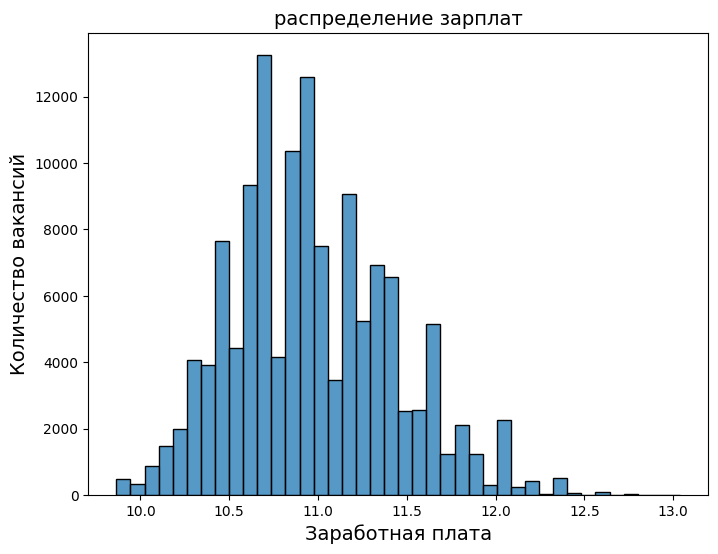

In [317]:
plt.figure(figsize=(8, 6))
sns.histplot(df_prod['salary_from_log'], bins = 40) 
plt.title('распределение зарплат', fontsize=14)
plt.xlabel('Заработная плата', fontsize=14)
plt.ylabel('Количество вакансий', fontsize=14)

Итоговый датасет df_prod содержит информацию с log и нормализованными значениями salary_from_log

In [319]:
df_prod['salary_from_log'].skew()

0.4566135873345938

In [321]:

cat = ['role_name', 'schedule_id', 'employment_id','experience_ord']
target = 'salary_from_log'

df_plot = df_prod[cat + [target]].copy()

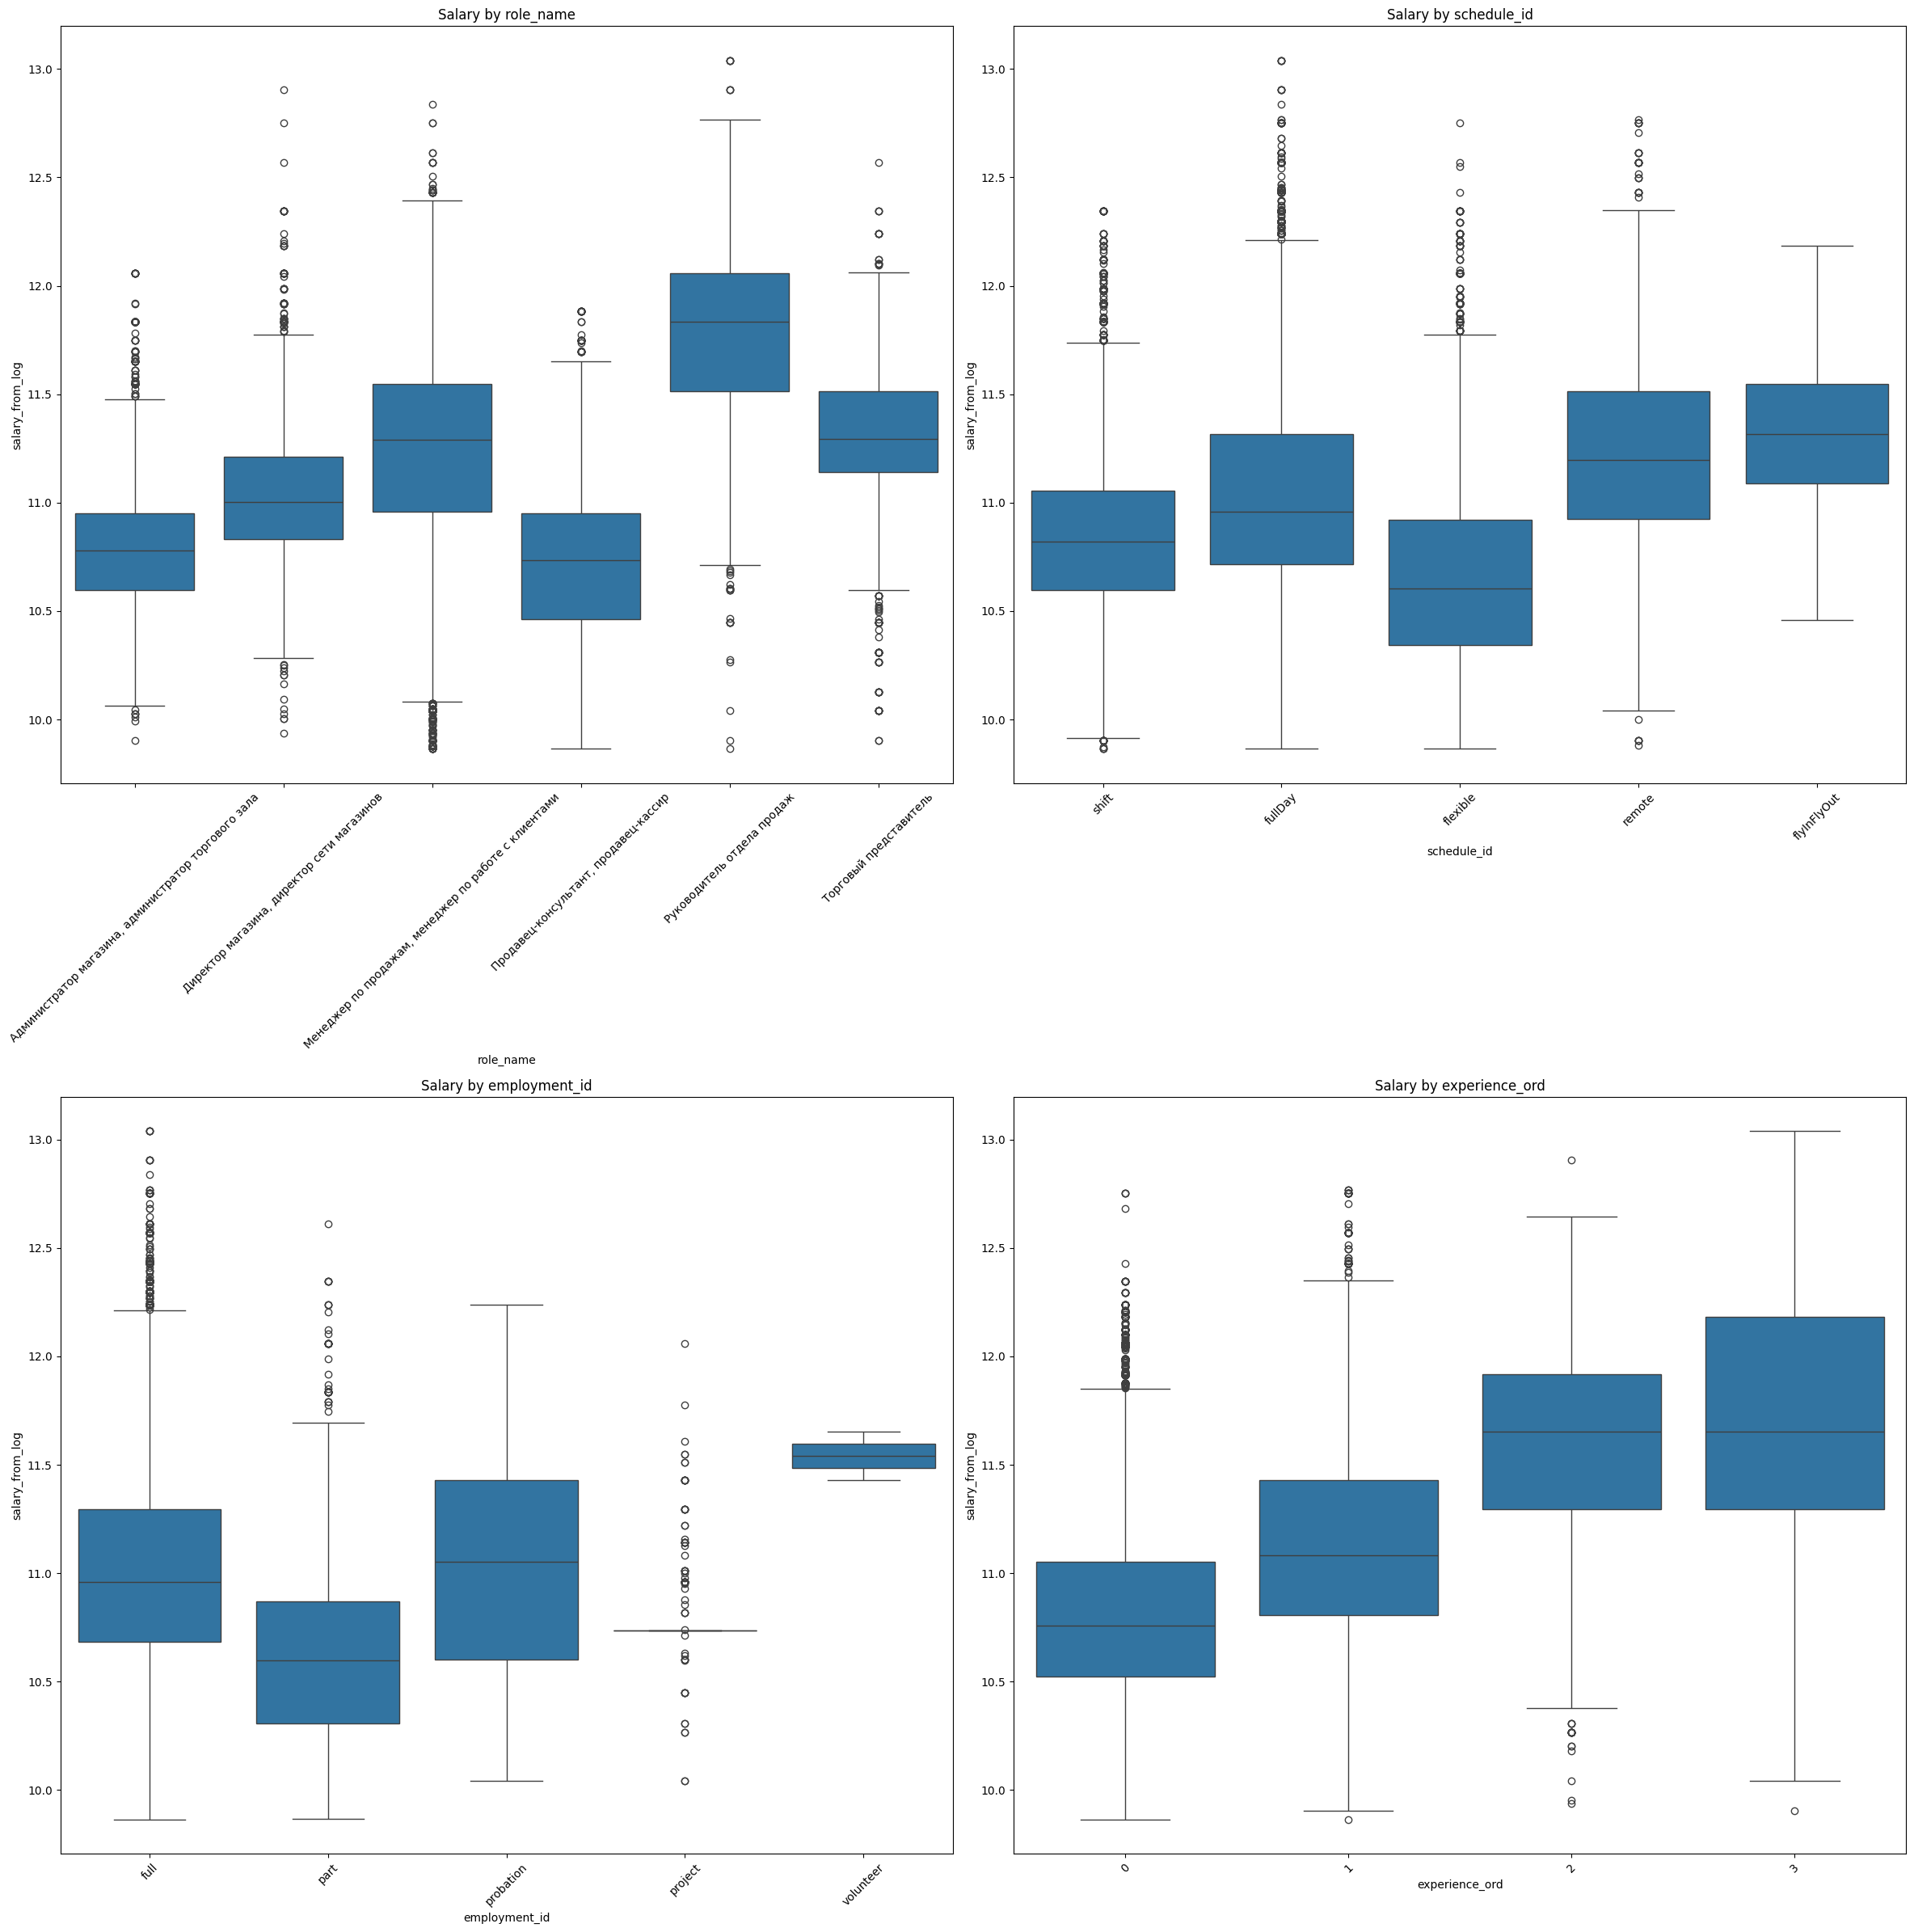

In [323]:
#Boxplots для категориальных признаков
plt.figure(figsize=(24, 24))

for i, col in enumerate(cat, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=col, y=target, data=df_plot)
    plt.xticks(rotation=45)
    plt.title(f'Salary by {col}')

plt.tight_layout()
plt.show()

Проведем первичный корреляционный анализ

In [325]:
df_prod.shape

(132540, 20)

Т.к опыт - ранговая переменная, используем корреляцию Спирмена

In [327]:
df_prod['experience_ord'].corr(df_prod['salary_from_log'], method='spearman')

0.38895044087030545

In [329]:
corr, p_value = spearmanr(df_prod['experience_ord'], df_prod['salary_from_log'])
print(corr, p_value)

0.38895044087030545 0.0


Вывод Корреляционный анализ показал умеренную положительную статистически значимую связь между уровнем требуемого опыта и логарифмированной заработной платой (Spearman ρ = 0.388, p < 0.001). Полученный результат подтверждает экономическую гипотезу о росте заработной платы по мере увеличения профессионального опыта.

In [331]:
groups = [
    group["salary_from_log"].values
    for name, group in df_prod.groupby("role_name")
]

stat, p = kruskal(*groups)
print(stat, p)

47269.20675165632 0.0


In [335]:
groups = [
    group["salary_from_log"].values
    for name, group in df_prod.groupby("schedule_id")
]

stat, p = kruskal(*groups)
print(stat, p)

10295.509004859923 0.0


In [337]:
groups = [
    group["salary_from_log"].values
    for name, group in df_prod.groupby("employment_id")
]

stat, p = kruskal(*groups)
print(stat, p)

6134.894935739726 0.0


**Вывод** Для оценки влияния номинальных категориальных признаков (профессиональная роль, тип графика работы, тип занятости) на уровень заработной платы использовался непараметрический критерий Краскела–Уоллиса.
Результаты показали статистически значимые различия между группами (p < 0.001), что свидетельствует о существенном влиянии данных факторов на формирование заработной платы.

Непараметрический критерий Краскела–Уоллиса выявил статистически значимые различия в уровне заработной платы между различными профессиональными ролями (H = 47269, p < 0.001), типами графика работы (H = 10295, p < 0.001) и типами занятости (H = 6134, p < 0.001).
Наибольший вклад в дифференциацию заработных плат вносит профессиональная роль, что соответствует экономической логике формирования оплаты труда.

In [339]:
df_prod.shape

(132540, 20)

In [268]:
df_prod.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 132540 entries, 594148 to 97486
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   name              132540 non-null  object 
 1   description       132540 non-null  object 
 2   role_id           132540 non-null  object 
 3   role_name         132540 non-null  object 
 4   key_skills        58565 non-null   object 
 5   experience_id     132540 non-null  object 
 6   experience_name   132540 non-null  object 
 7   schedule.id       132540 non-null  object 
 8   schedule.name     132540 non-null  object 
 9   employment_id     132540 non-null  object 
 10  employment.name   132540 non-null  object 
 11  address.lat_2     102738 non-null  float64
 12  address.lng_2     102738 non-null  float64
 13  address.city_new  102359 non-null  object 
 14  region_name       132540 non-null  object 
 15  salary.from       132540 non-null  float64
 16  salary.gross    

In [351]:
df_prod.to_csv('df_prod.csv', index=False)

# Подготовка данных для M1

In [110]:
features = ['role_name', 'experience_ord', 'schedule_id', 'employment_id','region_name']
target = 'salary_from_log'

df_m1_ols = df_prod[features + [target]].copy()

In [112]:
df_m1_ols.duplicated().sum()

91342

In [114]:
#удалим точные дубликаты
df_m1_ols = df_m1_ols.drop_duplicates().reset_index(drop=True)
print(f"После удаления дубликатов: {df_m1_ols.shape[0]} строк")

После удаления дубликатов: 41198 строк


In [116]:
group_sizes = df_m1_ols.groupby(features).size()
group_sizes.describe()

count    3723.000000
mean       11.065807
std        21.589478
min         1.000000
25%         1.000000
50%         3.000000
75%        11.000000
max       338.000000
dtype: float64

In [118]:
df_m1_ols.to_csv('df_m1_ols.csv', index=False)

# Подготовка данных для M2

In [22]:
df_prod = pd.read_csv ('df_prod.csv', low_memory=False)

In [24]:
df_new2=df_prod.copy()

In [26]:
# Получаем уникальные регионы
unique_regions = df_new2['region_name'].dropna().unique()

# Сортируем для удобства
unique_regions = np.sort(unique_regions)
unique_regions = pd.DataFrame(unique_regions)

# Выводим количество и первые 20 регионов для проверки
print(f"Всего уникальных регионов: {len(unique_regions)}")
print(unique_regions[:20])


unique_regions.to_excel('unique_regions_2302.xlsx')

Всего уникальных регионов: 89
                                  0
0                    Алтайский край
1                  Амурская область
2             Архангельская область
3              Астраханская область
4              Белгородская область
5                  Брянская область
6              Владимирская область
7             Волгоградская область
8               Вологодская область
9               Воронежская область
10     Донецкая Народная Республика
11                     Еврейская АО
12               Забайкальский край
13              Запорожская область
14               Ивановская область
15                Иркутская область
16  Кабардино-Балкарская республика
17          Калининградская область
18                Калужская область
19                  Камчатский край


Загрузим справочник экономических макрорегионов и координат региональных центров

In [28]:
reg_econ = pd.read_excel('reg_econ_0103v2.xlsx')

In [30]:
reg_econ.head()

,region_name,economic_region,center_lat,center_lon
0,Алтайский край,Западно-Сибирский,53.3474,83.7784
1,Амурская область,Дальневосточный,50.2907,127.5272
2,Архангельская область,Северный,64.5399,40.5158
3,Астраханская область,Поволжский,46.3497,48.0408
4,Белгородская область,Центрально-Чернозёмный,50.5954,36.5873


Посмотрим, есть ли пропуски в наименовании города и координат для 'Москва', 'Санкт-Петербург', 'Севастополь'

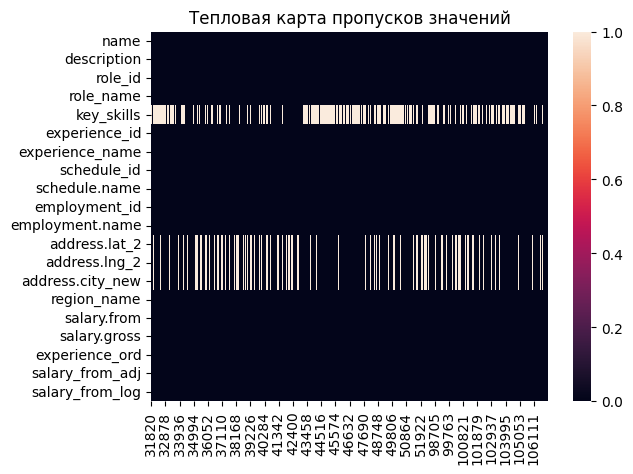

In [32]:
regions_to_check = ['Москва', 'Санкт-Петербург', 'Севастополь']
sns.heatmap(df_new2[df_new2['region_name'].isin(regions_to_check)].isna().T)
plt.title('Тепловая карта пропусков значений')
plt.show()

In [34]:
regions_to_check = ['Москва', 'Санкт-Петербург', 'Севастополь']

missing_city = df_new2.loc[
    df_new2['region_name'].isin(regions_to_check) & df_new2['address.city_new'].isna(),
    ['region_name', 'address.city_new']
]

missing_lat = df_new2.loc[
    df_new2['region_name'].isin(regions_to_check) & df_new2['address.lat_2'].isna(),
    ['region_name', 'address.lat_2']
]

missing_lon = df_new2.loc[
    df_new2['region_name'].isin(regions_to_check) & df_new2['address.lng_2'].isna(),
    ['region_name', 'address.lng_2']
]

print("Пропуски в address.city_new:\n", missing_city)
print("Пропуски в address.lat_2:\n", missing_lat)
print("Пропуски в address.lng_2:\n", missing_lon)

Пропуски в address.city_new:
             region_name address.city_new
31825            Москва              NaN
31826            Москва              NaN
31829            Москва              NaN
31832            Москва              NaN
31838            Москва              NaN
...                 ...              ...
107023  Санкт-Петербург              NaN
107024  Санкт-Петербург              NaN
107025  Санкт-Петербург              NaN
107027  Санкт-Петербург              NaN
107031  Санкт-Петербург              NaN

[6479 rows x 2 columns]
Пропуски в address.lat_2:
             region_name  address.lat_2
31825            Москва            NaN
31826            Москва            NaN
31829            Москва            NaN
31832            Москва            NaN
31838            Москва            NaN
...                 ...            ...
107023  Санкт-Петербург            NaN
107024  Санкт-Петербург            NaN
107025  Санкт-Петербург            NaN
107027  Санкт-Петербург            N

In [36]:
df_new2['region_group'] = df_new2['region_name'].apply(
    lambda x: x if x in regions_to_check else 'Все остальные регионы'
)
summary_missing = (
    df_new2
    .groupby('region_group')[['address.city_new', 'address.lat_2', 'address.lng_2']]
    .apply(lambda x: x.isna().sum())
)

summary_missing

,address.city_new,address.lat_2,address.lng_2
region_group,,,
Все остальные регионы,23702,23429,23429
Москва,4840,4759,4759
Санкт-Петербург,1639,1614,1614
Севастополь,0,0,0


Пропуски есть только для Мосвы и Санкт-Петербурга, заполним их значениями, соответсвующими этим регионам

In [38]:
regions_to_fill = ['Москва', 'Санкт-Петербург']

In [40]:
#Подгрузим региональные центры и их координаты
df_new2 = df_new2.merge(
    reg_econ[['region_name', 'economic_region','center_lat', 'center_lon']],
    on='region_name',
    how='left'
)

In [42]:
df_new2['economic_region'].isna().mean()

0.0

 заполним пропуски для 'Москва', 'Санкт-Петербург' по данным этих регионов

In [44]:
mask = (
    df_new2['region_name'].isin(regions_to_fill)
    & df_new2['address.city_new'].isna()
)

df_new2.loc[mask, 'address.city_new'] = df_new2.loc[mask, 'region_name']

In [46]:
mask_lat = (
    df_new2['region_name'].isin(regions_to_fill)
    & df_new2['address.lat_2'].isna()
)

df_new2.loc[mask_lat, 'address.lat_2'] = df_new2.loc[mask_lat, 'center_lat']

mask_lon = (
    df_new2['region_name'].isin(regions_to_fill)
    & df_new2['address.lng_2'].isna()
)

df_new2.loc[mask_lon, 'address.lng_2'] = df_new2.loc[mask_lon, 'center_lon']

summary_missing = (
    df_new2
    .groupby('region_group')[['address.city_new', 'address.lat_2', 'address.lng_2']]
    .apply(lambda x: x.isna().sum())
)
summary_missing

,address.city_new,address.lat_2,address.lng_2
region_group,,,
Все остальные регионы,23702,23429,23429
Москва,0,0,0
Санкт-Петербург,0,0,0
Севастополь,0,0,0


Убедились, что сейчас для Москва, Санкт-Петербург и Севастополь	пропусков в address.city_new	address.lat_2	address.lng_2 нет

In [48]:
df_new2['lat_missing'] = df_new2[['address.lat_2', 'address.lng_2']].isna().any(axis=1)
df_new2['geo_available'] = (~df_new2[['address.lat_2', 'address.lng_2']].isna().any(axis=1)).astype(int)

In [50]:
print(df_new2[['lat_missing', 'geo_available']].value_counts())

lat_missing  geo_available
False        1                109111
True         0                 23429
Name: count, dtype: int64


In [52]:
#Переведем координаты в радианы
df_new2['lat_rad'] = np.radians(df_new2['address.lat_2'])
df_new2['lon_rad'] = np.radians(df_new2['address.lng_2'])

df_new2['lat_sin'] = np.sin(df_new2['lat_rad'])
df_new2['lat_cos'] = np.cos(df_new2['lat_rad'])

df_new2['lon_sin'] = np.sin(df_new2['lon_rad'])
df_new2['lon_cos'] = np.cos(df_new2['lon_rad'])

In [54]:
df_new2[['address.lat_2',
        'lat_sin', 'lat_cos',
        'address.lng_2',
        'lon_sin', 'lon_cos']].head()

,address.lat_2,lat_sin,lat_cos,address.lng_2,lon_sin,lon_cos
0,52.53,0.793672,0.608346,85.18,0.996464,0.084026
1,53.35,0.802297,0.596925,83.67,0.993903,0.110255
2,NaN,NaN,NaN,NaN,NaN,NaN
3,52.51,0.793460,0.608623,85.14,0.996405,0.084721
4,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
df_new2[['lat_sin','lat_cos','lon_sin','lon_cos']].describe()

,lat_sin,lat_cos,lon_sin,lon_cos
count,109111.000000,109111.000000,109111.000000,109111.000000
mean,0.813939,0.576082,0.693272,0.632477
std,0.045282,0.059854,0.142291,0.314803
min,0.000000,0.349390,0.000000,-0.999063
25%,0.802297,0.551646,0.609592,0.585382
50%,0.826393,0.563093,0.636617,0.770624
75%,0.834078,0.596925,0.788333,0.792609
max,0.936977,1.000000,1.000000,1.000000


In [58]:
#Создадим geohash для тех строк, где есть координаты

def safe_geohash(lat, lon, precision):
    if pd.isna(lat) or pd.isna(lon):
        return np.nan
    return geohash2.encode(lat, lon, precision=precision)

In [60]:
#Создадим несколько уровней geohash
df_new2['geohash_4'] = df_new2.apply(
    lambda row: safe_geohash(row['address.lat_2'], row['address.lng_2'], 4),
    axis=1
)

df_new2['geohash_5'] = df_new2.apply(
    lambda row: safe_geohash(row['address.lat_2'], row['address.lng_2'], 5),
    axis=1
)

df_new2['geohash_6'] = df_new2.apply(
    lambda row: safe_geohash(row['address.lat_2'], row['address.lng_2'], 6),
    axis=1
)

In [62]:
df_new2[['address.lat_2', 'address.lng_2', 
        'geohash_4', 'geohash_5', 'geohash_6']].head()

,address.lat_2,address.lng_2,geohash_4,geohash_5,geohash_6
0,52.53,85.18,vckd,vckdf,vckdf6
1,53.35,83.67,vc7r,vc7rx,vc7rxb
2,NaN,NaN,NaN,NaN,NaN
3,52.51,85.14,vckd,vckd9,vckd9r
4,NaN,NaN,NaN,NaN,NaN


In [64]:
df_new2[['geohash_4','geohash_5','geohash_6']].nunique()

geohash_4     2683
geohash_5     7401
geohash_6    21540
dtype: int64

Определим расстояние до центра региона (координаты центров регионов мы подгрузили ранее)

In [66]:
#проверим что пропусков нет
df_new2[['center_lat', 'center_lon']].isna().mean()

center_lat    0.0
center_lon    0.0
dtype: float64

In [68]:
def haversine_vectorized(lat1, lon1, lat2, lon2):
    R = 6371  # км
    
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

In [70]:
#Расчёт distance_to_reg_center
#Считаем только там, где координаты есть
df_new2['distance_to_reg_center'] = np.where(
    df_new2['geo_available'] == 1,
    haversine_vectorized(
        df_new2['address.lat_2'],
        df_new2['address.lng_2'],
        df_new2['center_lat'],
        df_new2['center_lon']
    ),
    np.nan
)

In [72]:
df_new2['distance_to_reg_center'].describe()

count    109111.000000
mean         39.468727
std          95.205937
min           0.000000
25%           3.278097
50%           8.241991
75%          33.750301
max        7159.243986
Name: distance_to_reg_center, dtype: float64

In [74]:
#Проверим
df_new2.sort_values('distance_to_reg_center', ascending=True)[
    ['region_name', 'distance_to_reg_center']
].iloc[105000,:]

region_name               Республика Татарстан
distance_to_reg_center              206.514574
Name: 85752, dtype: object

In [76]:
#добавим логарифм расстояний
df_new2['log_distance_to_reg_center'] = np.log1p(df_new2['distance_to_reg_center'])

In [78]:
#проверим
df_new2[df_new2['region_name']=='Санкт-Петербург'][['region_name','address.lat_2','address.lng_2','center_lat','center_lon','distance_to_reg_center']]

,region_name,address.lat_2,address.lng_2,center_lat,center_lon,distance_to_reg_center
98173,Санкт-Петербург,59.9311,30.3609,59.9311,30.3609,0.000000
98174,Санкт-Петербург,59.9311,30.3609,59.9311,30.3609,0.000000
98175,Санкт-Петербург,59.9311,30.3609,59.9311,30.3609,0.000000
98176,Санкт-Петербург,59.8800,30.2700,59.9311,30.3609,7.613985
98177,Санкт-Петербург,59.9311,30.3609,59.9311,30.3609,0.000000
...,...,...,...,...,...,...
107027,Санкт-Петербург,59.9311,30.3609,59.9311,30.3609,0.000000
107028,Санкт-Петербург,59.9400,30.3600,59.9311,30.3609,0.990904
107029,Санкт-Петербург,59.8900,30.3900,59.9311,30.3609,4.849499
107030,Санкт-Петербург,59.8800,30.2700,59.9311,30.3609,7.613985


In [80]:
df_new2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132540 entries, 0 to 132539
Data columns (total 37 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   name                        132540 non-null  object 
 1   description                 132540 non-null  object 
 2   role_id                     132540 non-null  int64  
 3   role_name                   132540 non-null  object 
 4   key_skills                  58565 non-null   object 
 5   experience_id               132540 non-null  object 
 6   experience_name             132540 non-null  object 
 7   schedule_id                 132540 non-null  object 
 8   schedule.name               132540 non-null  object 
 9   employment_id               132540 non-null  object 
 10  employment.name             132540 non-null  object 
 11  address.lat_2               109111 non-null  float64
 12  address.lng_2               109111 non-null  float64
 13  address.city_n

## Morans

In [71]:
from libpysal.weights import KNN
from esda.moran import Moran

In [196]:
# берем только строки где есть координаты
df_moran = df_new2.dropna(subset=['address.lat_2','address.lng_2','salary_from_log']).copy()

In [198]:
df_moran.shape

(109111, 37)

In [194]:
df_moran.duplicated(subset=['address.lat_2', 'address.lng_2', 'salary_from_log']).sum()

0

In [200]:
df_moran = df_new2[['address.lat_2','address.lng_2','salary_from_log']].dropna()
df_moran = df_moran.drop_duplicates(subset=['address.lat_2', 'address.lng_2', 'salary_from_log'])

In [202]:
df_moran.shape

(83759, 3)

In [204]:
coords = df_moran[['address.lat_2','address.lng_2']].values
y = df_moran['salary_from_log'].values

#рассчитаем глобальный Moran
#10 ближайших соседей
w = KNN.from_array(coords, k=10)
w.transform = 'r'

mi = Moran(y, w)

print("Moran's I:", mi.I)
print("p-value:", mi.p_sim)

C:\PyEnvs\clean_env\lib\site-packages\libpysal\weights\weights.py:172: UserWarning: The weights matrix is not fully connected: 
 There are 983 disconnected components.
  warnings.warn(message)


Moran's I: 0.33339940250787803
p-value: 0.001


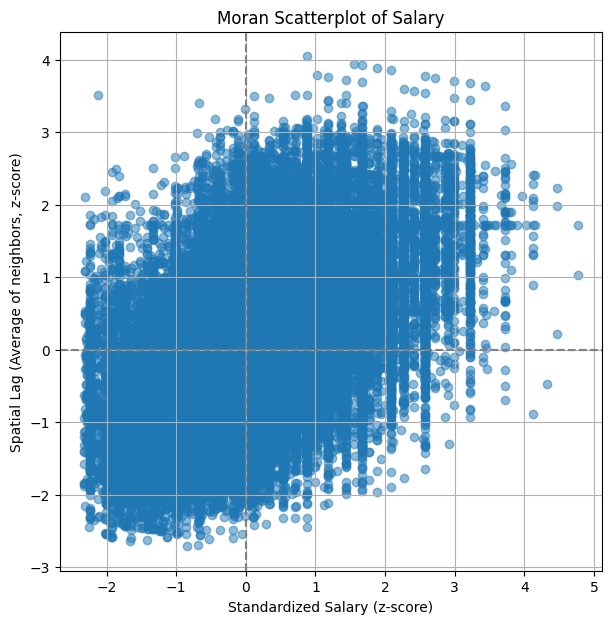

In [206]:
# рассчитаем spatial lag для графика
# spatial lag = среднее значение соседей по весам
y_lag = np.zeros_like(y)
for i, neighbors in enumerate(w.neighbors.values()):
    y_lag[i] = np.mean(y[list(neighbors)])

# стандартизируем значения для визуализации
y_z = (y - np.mean(y)) / np.std(y)
y_lag_z = (y_lag - np.mean(y_lag)) / np.std(y_lag)

#построим Moran Scatterplot
plt.figure(figsize=(7,7))
plt.scatter(y_z, y_lag_z, alpha=0.5)
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.xlabel('Standardized Salary (z-score)')
plt.ylabel('Spatial Lag (Average of neighbors, z-score)')
plt.title("Moran Scatterplot of Salary")
plt.grid(True)
plt.show()

In [208]:
# рассчитаем Локальный Moran на том же датасете
df_local = df_moran.copy()
values = df_local['salary_from_log'].values

In [212]:
df_local.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83759 entries, 0 to 132533
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   address.lat_2    83759 non-null  float64
 1   address.lng_2    83759 non-null  float64
 2   salary_from_log  83759 non-null  float64
dtypes: float64(3)
memory usage: 2.6 MB


In [214]:
# cоздаем весовую матрицу 10 ближайших соседей
w = KNN.from_array(coords, k=10)
w.transform = 'r'  # row-standardization

C:\PyEnvs\clean_env\lib\site-packages\libpysal\weights\weights.py:172: UserWarning: The weights matrix is not fully connected: 
 There are 983 disconnected components.
  warnings.warn(message)


In [216]:
# рассчитаем значения локального Moran's I с фиксированным seed для воспроизводимости
local_moran = Moran_Local(values, w, permutations=999, seed=7)

In [222]:
# добавляем локальные значения Moran в датафрейм
df_local['local_moran_I'] = local_moran.Is
df_local['local_moran_p'] = local_moran.p_sim
df_local['local_moran_quadrant'] = local_moran.q

In [224]:
# cоздаем булевы маски для каждого типа кластеров 
hotspots = (local_moran.q == 1) & (local_moran.p_sim < 0.05)  # HH
coldspots = (local_moran.q == 3) & (local_moran.p_sim < 0.05)  # LL
doughnuts = (local_moran.q == 2) & (local_moran.p_sim < 0.05)  # LH
diamonds = (local_moran.q == 4) & (local_moran.p_sim < 0.05)  # HL

In [226]:
# распределение кластеров среди значимых точек
sig_df = df_local[df_local['local_moran_p'] < 0.05]
cluster_counts = sig_df['local_moran_quadrant'].value_counts()
print("Распределение локальных кластеров:\n", cluster_counts)

Распределение локальных кластеров:
 local_moran_quadrant
3    16311
1    12954
2     3327
4     3307
Name: count, dtype: int64


In [ ]:
center_lat = 61.52401
center_lon = 105.318756

m = folium.Map(location=[center_lat, center_lon], zoom_start=4, tiles="CartoDB positron")

for idx, row in sig_df.iterrows():
    q = row['local_moran_quadrant']
    
    # Показываем только HH и LL на карте
    if q not in [1,3]:
        continue
    
    lat = row['address.lat_2']
    lon = row['address.lng_2']
    
    if q == 1:
        color = "red"
        label = "High-High cluster (High salary area)"
    else:
        color = "blue"
        label = "Low-Low cluster (Low salary area)"

    popup_text = f"""
    Cluster: {label}<br>
    Salary log: {row['salary_from_log']:.2f}<br>
    Local Moran I: {row['local_moran_I']:.3f}
    """

    folium.CircleMarker(
        location=[lat, lon],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.75,
        popup=popup_text
    ).add_to(m)
    
legend_html = '''
<div style="
position: fixed; 
bottom: 50px; left: 50px; width: 180px; height: 90px; 
border:2px solid grey; z-index:9999; font-size:14px;
background-color:white;
">
&nbsp;<b>LISA Cluster Legend</b><br>
&nbsp;<span style="background-color:red;color:red;">....</span>&nbsp;High-High (HH)<br>
&nbsp;<span style="background-color:blue;color:blue;">....</span>&nbsp;Low-Low (LL)
</div>
'''
m.get_root().html.add_child(Element(legend_html))
# m — объект карты с HH и LL кластерами
m

## Создадим итоговый датасет для M2

In [82]:
df_m2_geo = df_new2[[
    'salary_from_log',  # целевая
    'experience_ord',
    'role_name',
    'schedule_id',
    'employment_id',
    'economic_region',
    'geo_available',
    'region_name',
    'address.city_new',
    'lat_sin',
    'lat_cos',
    'lon_sin',
    'lon_cos',
    'geohash_4',
    'geohash_5',
    'geohash_6',
    'distance_to_reg_center',
]].copy()

In [84]:
#для 'distance_to_reg_center' добавим бинарный индикатор отсутствия расстояния
df_m2_geo['distance_missing'] = df_m2_geo['distance_to_reg_center'].isna().astype(int)

In [86]:
#заполним пропуски в address.city_new значением missing
df_m2_geo['address.city_new'] = df_m2_geo['address.city_new'].fillna('missing')

In [88]:
# список геохеш-столбцов
geohash_cols = ['geohash_4', 'geohash_5', 'geohash_6']

#т.к catboost не умеет работать с пропусками в категориальных значениях, подставим вместо пропусков Missing
# заменяем все NaN на строку 'missing' и приводим к типу str
df_m2_geo[geohash_cols] = df_m2_geo[geohash_cols].fillna('missing').astype(str)

In [90]:
#Проверим и удалим дубликаты строк:
df_m2_geo.duplicated().sum()

23812

In [92]:
df_m2_geo = df_m2_geo.drop_duplicates().copy()

In [94]:
df_m2_geo.shape

(108728, 18)

In [96]:
df_m2_geo.to_csv('df_m2_geo.csv', index=False)

Проверим пространственные признаки на мультиколлинеарность

In [102]:
# выбираем числовые признаки (кроме целевой)
numeric_cols = df_m2_geo.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'salary_from_log']

X = df_m2_geo[numeric_cols].copy()

# заменяем inf на NaN
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# убираем строки с NaN
X_clean = X.dropna()

# рассчитываем VIF
vif_data = pd.DataFrame()
vif_data['feature'] = X_clean.columns
vif_data['VIF'] = [variance_inflation_factor(X_clean.values, i) for i in range(X_clean.shape[1])]

# сортируем по убыванию VIF
vif_data = vif_data.sort_values(by='VIF', ascending=False)
print(vif_data)

                  feature        VIF
1                 lat_sin  82.384590
3                 lon_sin  47.880464
2                 lat_cos  45.558823
4                 lon_cos   9.374064
0          experience_ord   1.765295
5  distance_to_reg_center   1.204880
